### Vegetation health bands paper attempt
Regionally strong feedbacks between the atmosphere and terrestrial biosphere

Green et al. 2017

DOI: 10.1038/NGEO2957

------------------------------

Currently using variables:
- fAPAR + LAI (Sentinel)
- deltad (TROPOMI)
- precip (CHIRPS)

In [1]:
import sys
import xarray as xr
import numpy as np
from matplotlib import pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature
import geopandas as gpd
from shapely.geometry import mapping
from scipy.stats import spearmanr, pearsonr
import pandas as pd
import gc
import seaborn as sns
import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.tsa.vector_ar.var_model import VAR
from statsmodels.tsa.stattools import grangercausalitytests

import warnings
warnings.filterwarnings('ignore')

In [2]:
datap = "/Users/ellendyer/Documents/GitHub/Isotopes_F4R/plots/"
datac = "/Users/ellendyer/Documents/GitHub/Isotopes_F4R/data/"
dataf = "/Users/ellendyer/Documents/GitHub/Isotopes_F4R/data/analysed_fapar/"
datal = "/Users/ellendyer/Documents/GitHub/Isotopes_F4R/data/analysed_lai/"
datat = "/Users/ellendyer/Documents/GitHub/Isotopes_F4R/data/analysed_tropomi/"

band = 'eq'

In [3]:
fapar = xr.open_mfdataset(dataf+'*_'+band+'.nc')
precip = xr.open_dataset(datac+'chirps_10day_'+band+'.nc') 
lai = xr.open_mfdataset(datal+'lai_*_'+band+'.nc') 

In [4]:
tlist = []
for Y in range(2018,2025):
    t = xr.open_mfdataset(datat+'dD_'+str(Y)+'_10day_'+band+'.nc') 
    t = t.mean(dim=('scanline','ground_pixel')).load()
    tlist.append(t)
tropomi = xr.concat(tlist,dim='time')
    

In [5]:
fapar = fapar.mean(dim=('lat','lon')).load()
precip = precip.mean(dim=('lat','lon')).load()
lai = lai.mean(dim=('lat','lon')).load()

In [6]:
fapar_sns = fapar.to_dataframe()
precip_sns = precip.to_dataframe()
lai_sns = lai.to_dataframe()
tropomi_sns = tropomi.to_dataframe()
df = fapar_sns.join(precip_sns)
df = df.join(lai_sns)
df = df.join(tropomi_sns)
print(df)

#dfin=df

               fAPAR    precip       LAI      deltad
time                                                
2018-07-10  0.739174  3.519764  2.064247 -105.683746
2018-07-20  0.731139  2.393870  2.024307 -112.813461
2018-07-31  0.711830  3.488754  1.924838 -105.631516
2018-08-10  0.690628  2.334528  1.827673  -96.356483
2018-08-20  0.680627  3.704945  1.778297 -101.348236
...              ...       ...       ...         ...
2024-11-20  0.711375  5.737393  1.890827 -133.647858
2024-11-30  0.698641  3.997893  1.821284 -132.457352
2024-12-10  0.671419  3.320154  1.685426 -119.651443
2024-12-20  0.632701  4.303280  1.507160 -111.248856
2024-12-31  0.590161  3.609296  1.327083 -117.145164

[228 rows x 4 columns]


In [7]:
from statsmodels.tsa.stattools import adfuller

#df = dfin.diff().dropna()

def check_stationarity(timeseries):
    result = adfuller(timeseries)
    print('ADF Statistic:', result[0])
    print('p-value:', result[1])
    for key, value in result[4].items():
        print('Critial Values:')
        print(f'   {key}, {value}')

# Check stationarity of each time series
for column in df.columns:
    print(f'\nColumn: {column}')
    check_stationarity(df[column])


Column: fAPAR
ADF Statistic: -4.999204461037218
p-value: 2.2273752533498537e-05
Critial Values:
   1%, -3.459884913337196
Critial Values:
   5%, -2.8745310704320794
Critial Values:
   10%, -2.573693840082908

Column: precip
ADF Statistic: -4.01091135580995
p-value: 0.0013544416372082615
Critial Values:
   1%, -3.461136478222043
Critial Values:
   5%, -2.875078880098608
Critial Values:
   10%, -2.5739861168199027

Column: LAI
ADF Statistic: -6.592302746236754
p-value: 7.064622105149396e-09
Critial Values:
   1%, -3.4596204846395824
Critial Values:
   5%, -2.8744153028455948
Critial Values:
   10%, -2.5736320761218576

Column: deltad
ADF Statistic: -6.827536552605252
p-value: 1.9306688066801364e-09
Critial Values:
   1%, -3.460154163751041
Critial Values:
   5%, -2.874648939216792
Critial Values:
   10%, -2.5737567259151044


In [8]:
# Fit the VAR model
model = VAR(df)
fitted_model = model.fit(maxlags=18, ic='aic')


#print(model.select_order(18))
#print(fitted_model.aic)
#print(fitted_model.summary())




#a = fitted_model.plot()

test = fitted_model.test_causality('deltad', ['fAPAR'], kind='f',signif=0.01)
print(test.summary())
#cov = fitted_model.acorr()
#print(cov)

Granger causality F-test. H_0: fAPAR does not Granger-cause deltad. Conclusion: reject H_0 at 1% significance level.
Test statistic Critical value p-value         df        
--------------------------------------------------------
         2.941          2.535   0.003 (8, np.int64(748))
--------------------------------------------------------


In [9]:
def granger_causality_matrix(data, max_lag):
    variables = data.columns
    matrix1 = pd.DataFrame(np.zeros((len(variables), len(variables))), columns=variables, index=variables)
    matrix2 = pd.DataFrame(np.zeros((len(variables), len(variables))), columns=variables, index=variables)
    for col in matrix1.columns:
        for row in matrix1.index:
            test_result = grangercausalitytests(data[[row, col]], [max_lag], verbose=False)
            p_values = [round(test[0]['ssr_chi2test'][1], 4) for test in test_result.values()]
            min_p_value = np.min(p_values)
            min_p_arg = np.argmin(p_values)
            matrix1.loc[row, col] = min_p_value
            matrix2.loc[row, col] = min_p_arg
    matrix1.columns = [var + '_x' for var in variables]
    matrix1.index = [var + '_y' for var in variables]
    return matrix1,matrix2

# Perform Granger Causality tests
gc_pval,gc_lag = granger_causality_matrix(df, max_lag=8)
print(gc_pval)
print(gc_lag)

print(gc_pval.loc['fAPAR_y','precip_x'])

          fAPAR_x  precip_x   LAI_x  deltad_x
fAPAR_y    1.0000    0.0000  0.0000    0.0029
precip_y   0.0005    1.0000  0.0004    0.0099
LAI_y      0.0000    0.0000  1.0000    0.0039
deltad_y   0.0902    0.0002  0.0483    1.0000
        fAPAR  precip  LAI  deltad
fAPAR     0.0     0.0  0.0     0.0
precip    0.0     0.0  0.0     0.0
LAI       0.0     0.0  0.0     0.0
deltad    0.0     0.0  0.0     0.0
0.0


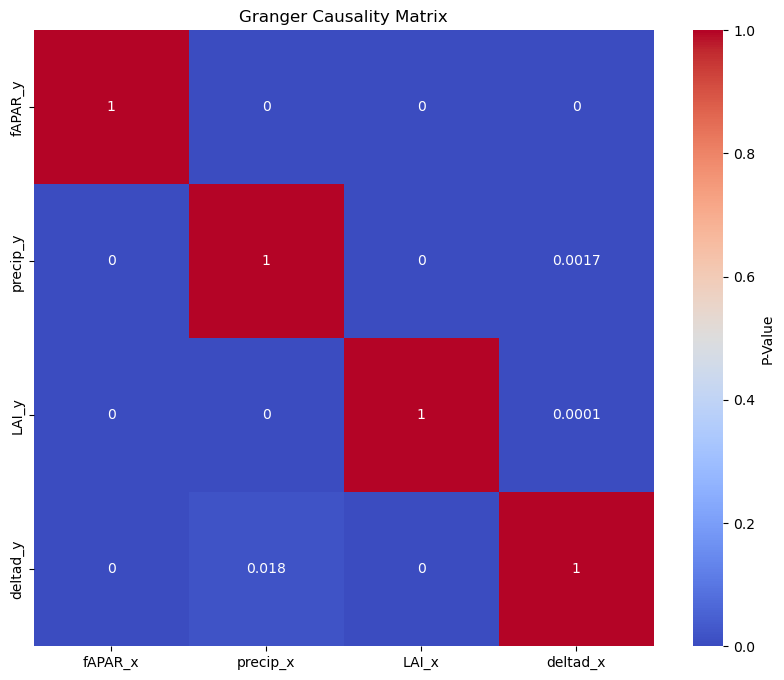

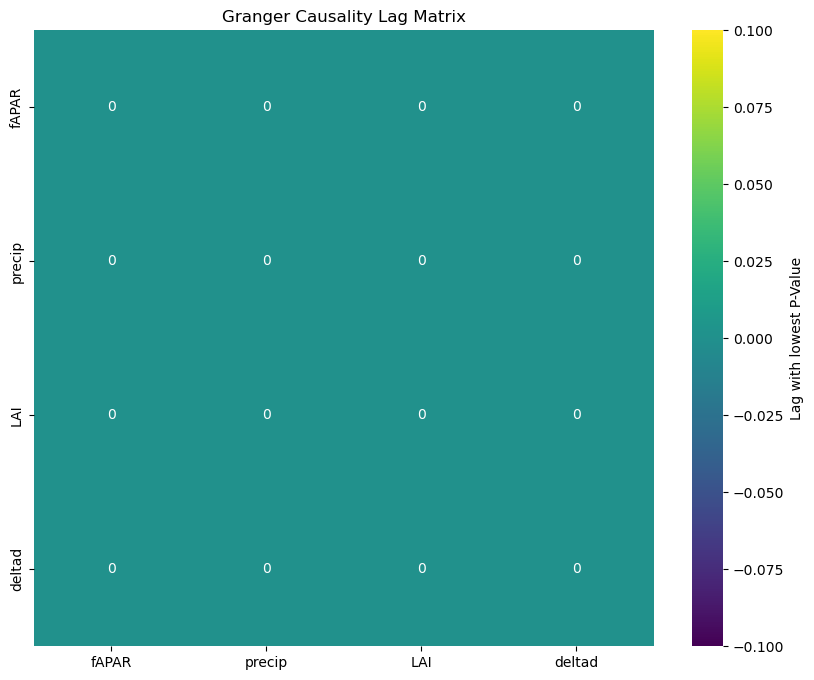

In [10]:
import seaborn as sns
import matplotlib.pyplot as plt

# Example Granger causality matrix
matrix1,matrix2 = granger_causality_matrix(df, max_lag=15)

# Visualize the Granger causality matrix
plt.figure(figsize=(10, 8))
sns.heatmap(matrix1, annot=True, cmap='coolwarm', cbar_kws={'label': 'P-Value'})
plt.title('Granger Causality Matrix')
plt.show()

plt.figure(figsize=(10, 8))
sns.heatmap(matrix2, annot=True, cmap='viridis', cbar_kws={'label': 'Lag with lowest P-Value'})
plt.title('Granger Causality Lag Matrix')
plt.show()
